In [ ]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import numpy as np
import pandas as pd

def find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "scripts" / "generate_finer_cam_panderm.py").exists():
            return p.resolve()
    raise FileNotFoundError


REPO = find_repo_root()
for extra in [REPO, REPO / "external" / "PanDerm" / "classification"]:
    if str(extra) not in sys.path:
        sys.path.insert(0, str(extra))

from src.thesis.config import *
from src.thesis import data, models, cams, metrics, plotting, audit

EV = data.load_eval()
LESION = data.load_lesions(EV)
QC = data.load_qc()
HUM = data.load_hum(QC, LESION)
X_TEST, Y_MEL, ID_TEST, TEST_DF = data.load_test()
M0, M5 = models.ck5("ha0"), models.ck5("ha5")

AUD = audit.run_audit(EV, LESION, HUM, X_TEST, Y_MEL, ID_TEST, QC, M0, M5)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
                                       check  pass         detail
                            index convention  True               
                  test split 987 with 54 MEL  True       987 / 54
                  no annotated image in test  True               
                 lesion masks non degenerate  True             34
             HUM has positives and negatives  True             31
                          ha0 and ha5 differ  True               
                 target follows ground truth  True               
            FinerCAM alpha 0 equals Grad-CAM  True       1.000000
                          AUC rank invariant  True               
                          AUC argument order  True               
              HUM identical to 14d reference  True 31 ref, 31 new
            centre baseline reproduces 0.828  True          0.828
aligned target vs clinician reproduces 0.743  True    

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import math
from src.thesis.plotting import overlay

INCLUDE_F2 = True          # False gives Shelley's 4 column design
F2_FOLD, F2_BETA = 0, 5.0
PLAN = {"TP": 5, "TN": 5, "FP": 3, "FN": 3}
CONF = 0.9                 # confident means p >= 0.9 or p <= 0.1

# ---- predictions of the aligned model ---------------------------------------
T = TEST_DF.copy()
T["p_mel"] = models.predict_mel(M5, X_TEST)
T["pred"] = np.where(T.p_mel >= 0.5, "MEL", "NV")
T["case"] = np.select(
    [(T.gt_label == "MEL") & (T.pred == "MEL"), (T.gt_label == "NV") & (T.pred == "NV"),
     (T.gt_label == "MEL") & (T.pred == "NV"), (T.gt_label == "NV") & (T.pred == "MEL")],
    ["TP", "TN", "FN", "FP"])
T["conf"] = np.maximum(T.p_mel, 1 - T.p_mel)
assert not (set(T.image_id) & set(QC.Image_ID)), "annotated image in study pool"

# ---- confident cases only, random inside the confident pool -----------------
sel = []
for c, n in PLAN.items():
    pool = T[(T.case == c) & (T.conf >= CONF)]
    if len(pool) >= n:
        pick = pool.sample(n, random_state=SEED)
        note = f"{len(pool)} confident, sampled {n}"
    else:
        pick = T[T.case == c].nlargest(n, "conf")
        note = f"only {len(pool)} confident, took the {n} most confident"
    sel.append(pick)
    print(f"  {c}: {note}, confidence {pick.conf.min():.2f} to {pick.conf.max():.2f}")
STUDY = pd.concat(sel).sample(frac=1, random_state=SEED).reset_index(drop=True)
STUDY["case_no"] = np.arange(1, len(STUDY) + 1)

METHODS = ["unaligned Grad-CAM", "aligned Grad-CAM", "Diff-CAM", "FinerCAM 0.6"]
if INCLUDE_F2:
    METHODS.append("concept-aligned Grad-CAM")
    MF2 = models.f2(5.0, F2_BETA, F2_FOLD)
LETTERS = list("ABCDE")[:len(METHODS)]

# ---- balanced column order, fixed before any map is computed ----------------
cap = math.ceil(len(STUDY) / len(METHODS)) + 1
for s in range(SEED, SEED + 2000):
    rng = np.random.default_rng(s)
    orders = [list(rng.permutation(METHODS)) for _ in range(len(STUDY))]
    pos = pd.DataFrame([(m, LETTERS[o.index(m)]) for o in orders for m in METHODS],
                       columns=["method", "letter"])
    if pd.crosstab(pos.method, pos.letter).values.max() <= cap:
        break
print(f"\ncolumn order seed {s}, max {cap} per letter")
print(pd.crosstab(pos.method, pos.letter).to_string())

def study_maps(rel, pred):
    x = data.to_tensor(data.native(rel))
    out = {"unaligned Grad-CAM": cams.target_ref(M0, x, pred)[0],
           "aligned Grad-CAM": cams.target_ref(M5, x, pred)[0],
           "Diff-CAM": cams.diff_cam(M5, x, pred),
           "FinerCAM 0.6": cams.finer_cam(M5, x, pred, 0.6)}
    if INCLUDE_F2:
        out["concept-aligned Grad-CAM"] = cams.target_ref(MF2, x, pred)[0]
    return out

MAPS = {r.image_id: study_maps(r.image_rel_path, r.pred) for _, r in STUDY.iterrows()}
RGB = {r.image_id: data.rgb224(r.image_rel_path) for _, r in STUDY.iterrows()}
NC = len(METHODS) + 1

def page_text(pdf, title, body, size=(8.3, 5.8)):
    f, a = plt.subplots(figsize=size)
    a.axis("off")
    a.text(0, 1, title, fontsize=15, fontweight="bold", va="top")
    a.text(0, .87, body, fontsize=10.5, va="top", family="monospace" if "Case" in body else None)
    pdf.savefig(f)
    plt.close(f)

# ---- blinded PDF for Florentia: instructions, answer sheet, cases -----------
pdf_path = OUT / "clinician_study.pdf"
with PdfPages(pdf_path) as pdf:
    page_text(pdf, "Explanation preference study",
              f"Each page shows one dermoscopic image and {len(METHODS)} heat maps, "
              f"{LETTERS[0]} to {LETTERS[-1]}.\n"
              "All maps explain the SAME model prediction, stated above the image.\n"
              "Warmer colour means the region contributed more to that prediction.\n"
              "The order of the letters changes on every page.\n\n"
              "Question for each case:\n"
              "   Which heat map best highlights the regions that you would consider\n"
              "   clinically relevant to the predicted diagnosis?\n\n"
              "Please note one letter per case on the next page.\n"
              "Optionally, rank all maps from best to worst.")
    blanks = "  ".join(["___"] * len(METHODS))
    page_text(pdf, "Answers",
              "\n".join(f"Case {i + 1:2d}    best: ____    ranking (optional): {blanks}\n"
                        for i in range(len(STUDY))),
              size=(8.3, 11.7))
    for (_, row), order in zip(STUDY.iterrows(), orders):
        fig, ax = plt.subplots(1, NC, figsize=(3.2 * NC, 3.9))
        ax[0].imshow(RGB[row.image_id])
        ax[0].set_title("image", fontsize=11)
        for j, m in enumerate(order):
            overlay(ax[j + 1], RGB[row.image_id], MAPS[row.image_id][m], thresh=0.28)
            ax[j + 1].set_title(LETTERS[j], fontsize=15, fontweight="bold")
        for a_ in ax:
            a_.set_xticks([]); a_.set_yticks([])
        lab = "melanoma" if row.pred == "MEL" else "nevus"
        fig.suptitle(f"Case {row.case_no}      Model predicts: {lab}", fontsize=13)
        pdf.savefig(fig)
        plt.close(fig)

# ---- labelled preview for YOU only, fixed column order, names visible -------
with PdfPages(OUT / "clinician_study_PREVIEW_labelled.pdf") as pdf:
    for _, row in STUDY.iterrows():
        fig, ax = plt.subplots(1, NC, figsize=(3.2 * NC, 3.9))
        ax[0].imshow(RGB[row.image_id])
        ax[0].set_title(f"{row.image_id}\ngt {row.gt_label}  pred {row.pred}  "
                        f"p_mel {row.p_mel:.2f}", fontsize=8)
        for j, m in enumerate(METHODS):
            overlay(ax[j + 1], RGB[row.image_id], MAPS[row.image_id][m], thresh=0.28)
            ax[j + 1].set_title(m, fontsize=9)
        for a_ in ax:
            a_.set_xticks([]); a_.set_yticks([])
        fig.suptitle(f"Case {row.case_no}   {row.case}", fontsize=11)
        pdf.savefig(fig)
        plt.close(fig)

KEY = pd.DataFrame([{"case_no": r.case_no, "image_id": r.image_id, "letter": LETTERS[j],
                     "method": m, "gt": r.gt_label, "pred": r.pred, "case": r.case,
                     "p_mel": round(float(r.p_mel), 3)}
                    for (_, r), o in zip(STUDY.iterrows(), orders) for j, m in enumerate(o)])
KEY.to_csv(OUT / "clinician_study_KEY_do_not_send.csv", index=False)
STUDY.to_csv(OUT / "clinician_study_cases.csv", index=False)
print(f"\nblinded  {pdf_path}\npreview  {OUT / 'clinician_study_PREVIEW_labelled.pdf'}")

  TP: 19 confident, sampled 5, confidence 0.92 to 0.94
  TN: 351 confident, sampled 5, confidence 0.90 to 0.97
  FP: only 0 confident, took the 3 most confident, confidence 0.88 to 0.89
  FN: only 0 confident, took the 3 most confident, confidence nan to nan

column order seed 2044, max 4 per letter
letter                    A  B  C  D  E
method                                 
Diff-CAM                  4  2  2  3  2
FinerCAM 0.6              1  1  4  4  3
aligned Grad-CAM          3  3  2  2  3
concept-aligned Grad-CAM  1  3  2  3  4
unaligned Grad-CAM        4  4  3  1  1

blinded  /Users/choekyelnyungmartsang/Developer/master-thesis/results/final/clinician_study.pdf
preview  /Users/choekyelnyungmartsang/Developer/master-thesis/results/final/clinician_study_PREVIEW_labelled.pdf


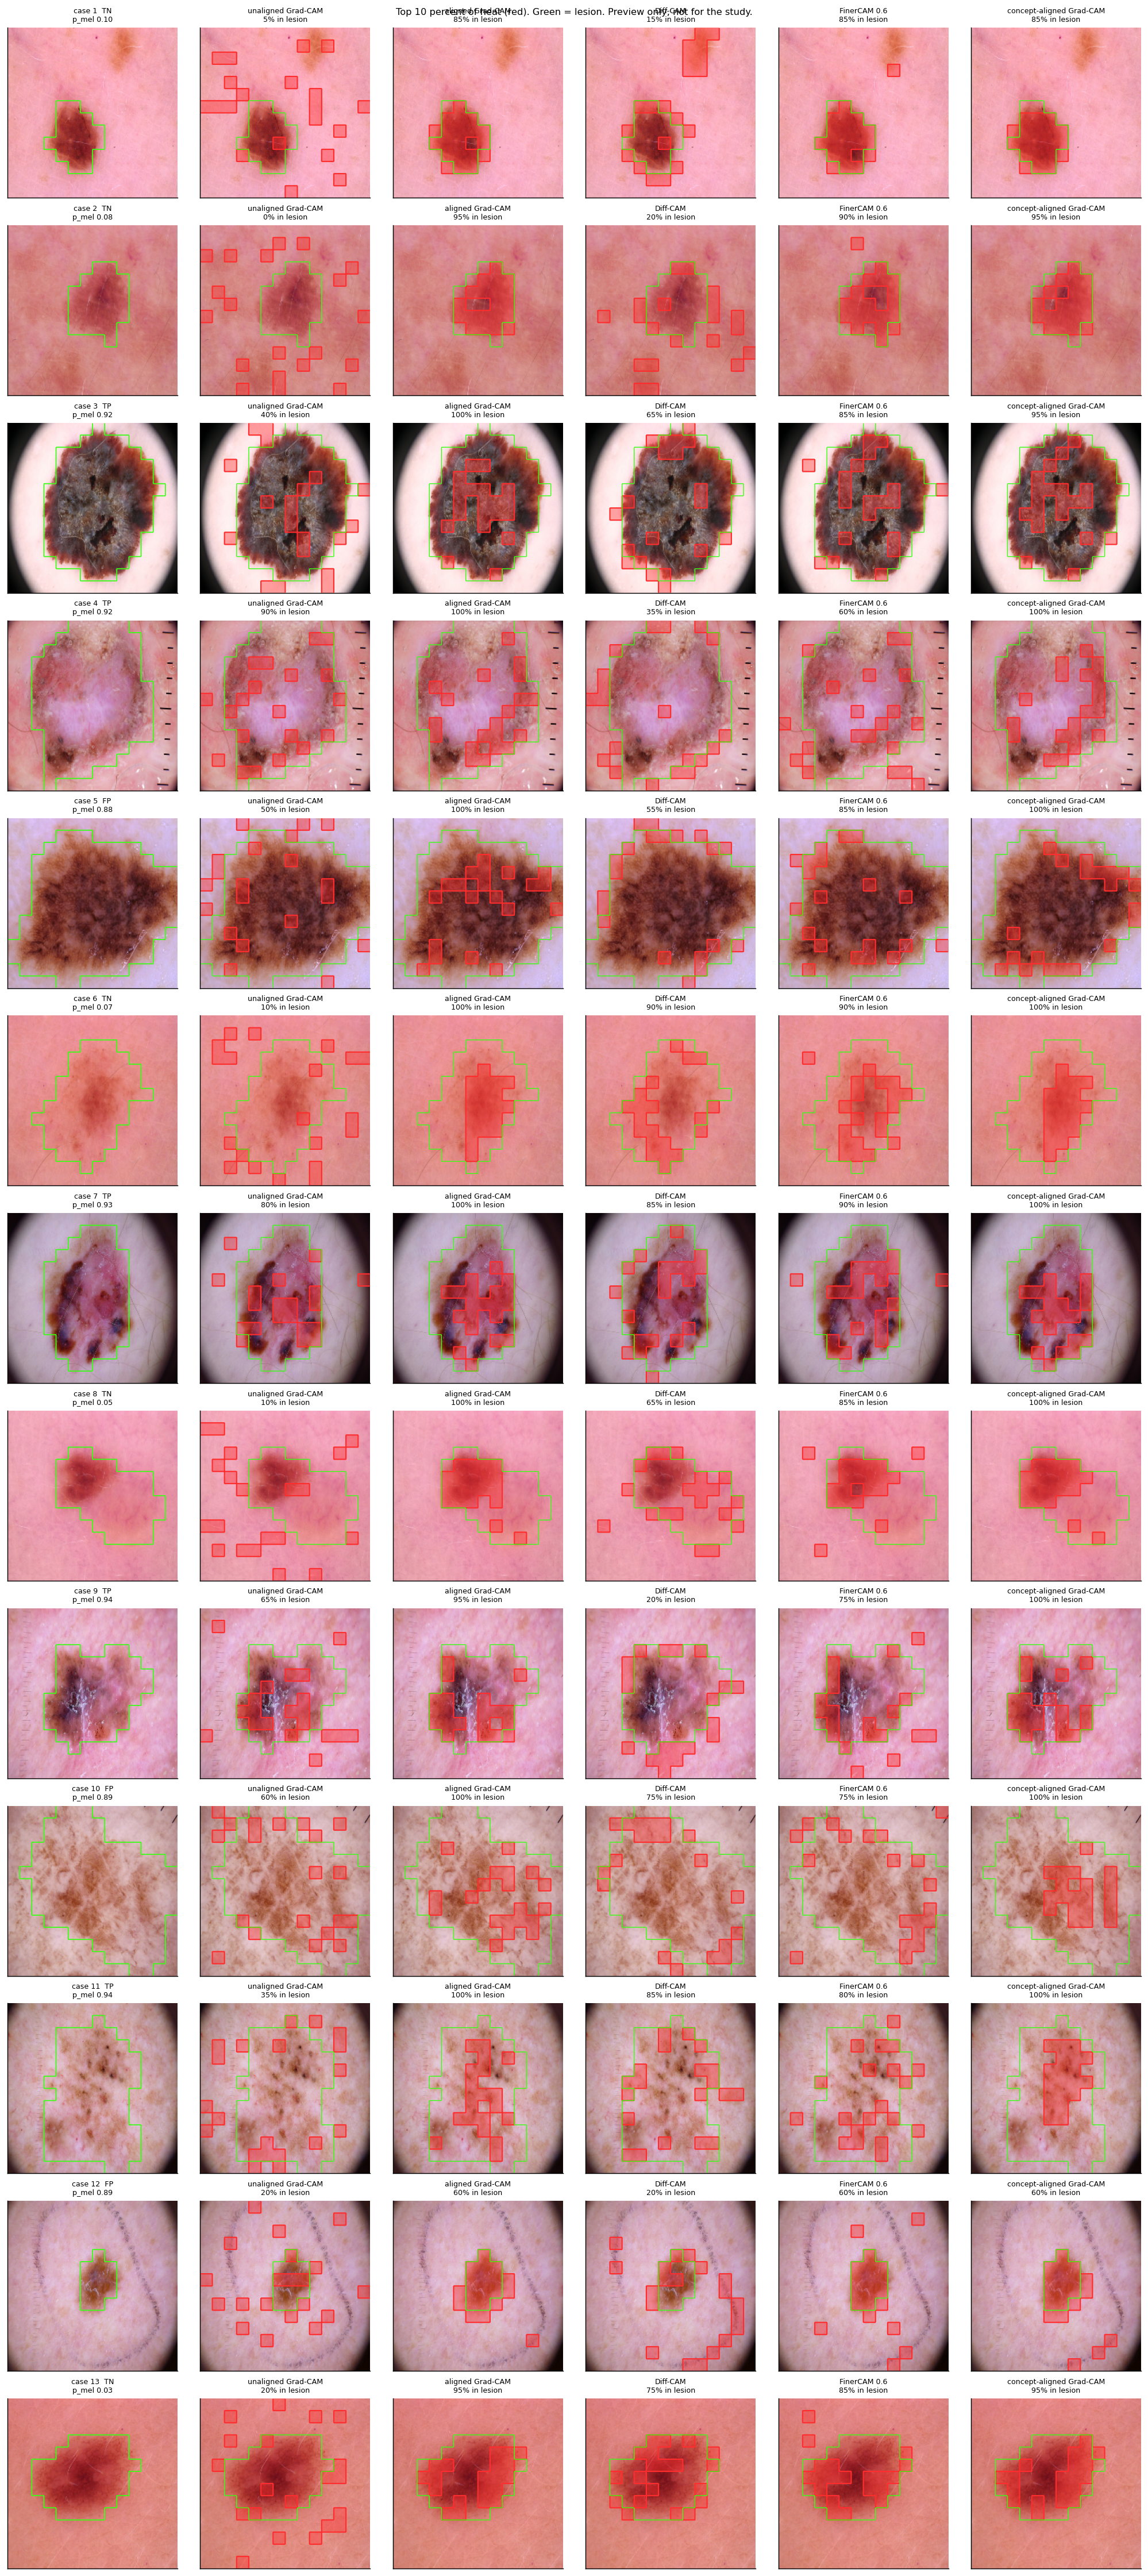

In [7]:
import matplotlib as mpl
from src.thesis.plotting import g224, outline, C_LESION
from PIL import Image

def top_mask(v, frac=TOP_FRAC):
    k = max(1, int(round(frac * v.size)))
    m = np.zeros(v.size, bool)
    m[np.argsort(-np.asarray(v).ravel())[:k]] = True
    return m.reshape(v.shape)

def draw_top(ax, rgb, hot, color="#FF2D2D"):
    ax.imshow(rgb)
    ov = np.zeros((*g224(hot).shape, 4))
    ov[g224(hot) > .5] = [*mpl.colors.to_rgb(color), .40]
    ax.imshow(ov)
    outline(ax, hot, color, lw=1.2)
    ax.set_xticks([]); ax.set_yticks([])

NC = len(METHODS) + 1
fig, ax = plt.subplots(len(STUDY), NC, figsize=(2.6 * NC, 2.7 * len(STUDY)))
for i, (_, row) in enumerate(STUDY.iterrows()):
    rgb = RGB[row.image_id]
    L = data.to_grid(np.array(Image.open((HAM / str(row.mask_rel_path)).resolve())
                              .convert("L")) > 127)
    ax[i, 0].imshow(rgb)
    outline(ax[i, 0], L, C_LESION, lw=1.0)
    ax[i, 0].set_xticks([]); ax[i, 0].set_yticks([])
    ax[i, 0].set_title(f"case {row.case_no}  {row.case}\np_mel {row.p_mel:.2f}", fontsize=7)
    for j, m in enumerate(METHODS):
        hot = top_mask(MAPS[row.image_id][m])
        draw_top(ax[i, j + 1], rgb, hot)
        outline(ax[i, j + 1], L, C_LESION, lw=0.8)
        ax[i, j + 1].set_title(f"{m}\n{(hot & L).sum() / hot.sum():.0%} in lesion", fontsize=7)
fig.suptitle("Top 10 percent of heat (red). Green = lesion. Preview only, not for the study.",
             fontsize=9)
fig.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

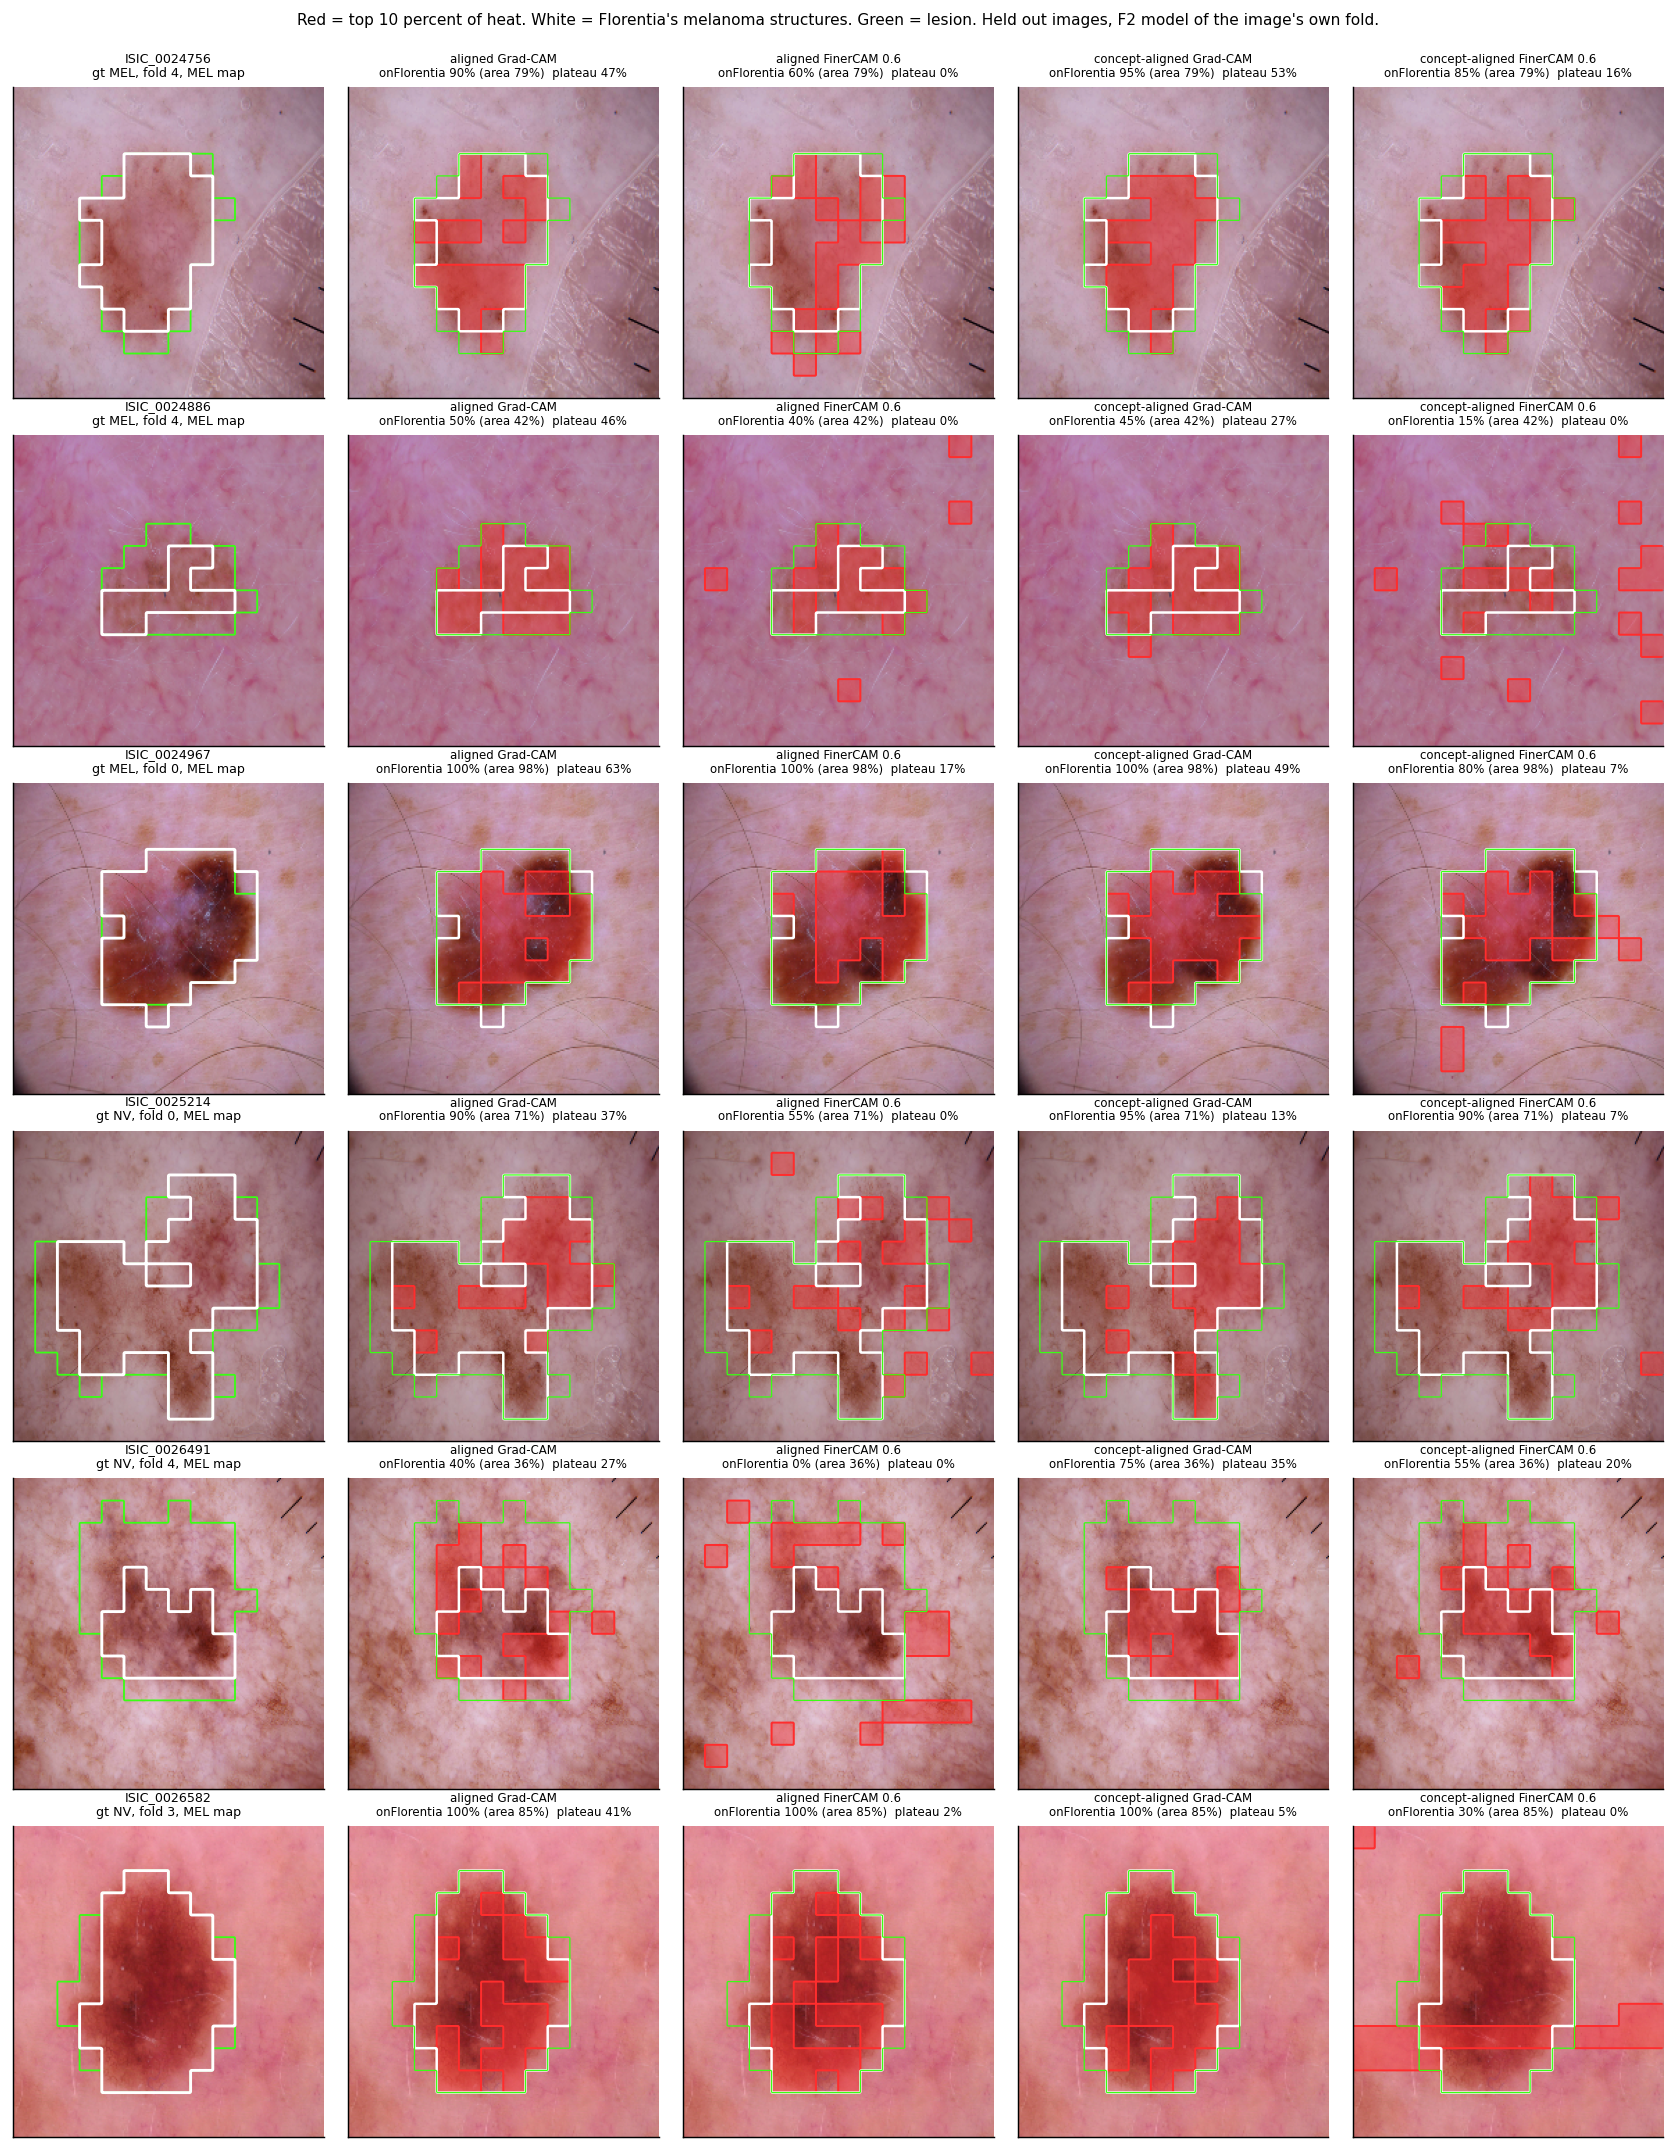

In [8]:
from PIL import Image
import matplotlib as mpl
from src.thesis.plotting import g224, outline, C_LESION

MAP_CLASS = "MEL"          # "MEL" = melanoma map on every image, "gt" = ground truth class map
FOLD = data.fold_of_heldout()
gt_of = EV.gt_label.to_dict()
held = sorted(i for i in FOLD if i in HUM)
SHOW = ([i for i in held if gt_of[i] == "MEL"][:3]
        + [i for i in held if gt_of[i] == "NV"][:3])

F2M = {}
def f2m(k):
    if k not in F2M:
        F2M[k] = models.f2(5.0, 5.0, k)
    return F2M[k]

COLS = ["aligned Grad-CAM", "aligned FinerCAM 0.6",
        "concept-aligned Grad-CAM", "concept-aligned FinerCAM 0.6"]

def four_maps(x, lab, mf2):
    return {COLS[0]: cams.target_ref(M5, x, lab)[0],
            COLS[1]: cams.finer_cam(M5, x, lab, 0.6),
            COLS[2]: cams.target_ref(mf2, x, lab)[0],
            COLS[3]: cams.finer_cam(mf2, x, lab, 0.6)}

def top_mask(v, frac=TOP_FRAC):
    k = max(1, int(round(frac * v.size)))
    m = np.zeros(v.size, bool)
    m[np.argsort(-np.asarray(v).ravel())[:k]] = True
    return m.reshape(v.shape)

def draw_top(ax, rgb, hot, color="#FF2D2D"):
    ax.imshow(rgb)
    ov = np.zeros((*g224(hot).shape, 4))
    ov[g224(hot) > .5] = [*mpl.colors.to_rgb(color), .40]
    ax.imshow(ov)
    outline(ax, hot, color, lw=1.1)
    ax.set_xticks([]); ax.set_yticks([])

fig, ax = plt.subplots(len(SHOW), 5, figsize=(13, 2.8 * len(SHOW)))
for i, iid in enumerate(SHOW):
    r = EV.loc[iid]
    k = FOLD[iid]
    lab = "MEL" if MAP_CLASS == "MEL" else r.gt_label
    x = data.to_tensor(data.native(r.image_rel_path))
    rgb = data.rgb224(r.image_rel_path)
    L, U = LESION[iid], HUM[iid]
    M = four_maps(x, lab, f2m(k))

    ax[i, 0].imshow(rgb)
    outline(ax[i, 0], L, C_LESION, lw=1.0)
    outline(ax[i, 0], U, "#FFFFFF", lw=1.6)
    ax[i, 0].set_xticks([]); ax[i, 0].set_yticks([])
    ax[i, 0].set_title(f"{iid}\ngt {r.gt_label}, fold {k}, {lab} map", fontsize=7)

    for j, c in enumerate(COLS):
        v = M[c]
        hot = top_mask(v)
        draw_top(ax[i, j + 1], rgb, hot)
        outline(ax[i, j + 1], U, "#FFFFFF", lw=1.4)
        outline(ax[i, j + 1], L, C_LESION, lw=0.7)
        on_u = (hot & U).sum() / hot.sum()
        sat = (v[L] > 0.9).mean()
        ax[i, j + 1].set_title(f"{c}\nonFlorentia {on_u:.0%} (area {U[L].mean():.0%})"
                               f"  plateau {sat:.0%}", fontsize=6.5)
fig.suptitle("Red = top 10 percent of heat. White = Florentia's melanoma structures. "
             "Green = lesion. Held out images, F2 model of the image's own fold.", fontsize=8.5)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()
F2M.clear()

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import math
from src.thesis.plotting import overlay, draw_top_smooth
from src.thesis.metrics import top_mask

CONF = 0.9
PLAN = {"TP": 3, "TN": 3, "FP": 2, "FN": 2}

T = TEST_DF.copy()
T["p_mel"] = models.predict_mel(M5, X_TEST)
T["pred"] = np.where(T.p_mel >= 0.5, "MEL", "NV")
T["case"] = np.select(
    [(T.gt_label == "MEL") & (T.pred == "MEL"), (T.gt_label == "NV") & (T.pred == "NV"),
     (T.gt_label == "MEL") & (T.pred == "NV"), (T.gt_label == "NV") & (T.pred == "MEL")],
    ["TP", "TN", "FN", "FP"])
T["conf"] = np.maximum(T.p_mel, 1 - T.p_mel)
assert not (set(T.image_id) & set(QC.Image_ID))

def select(seed, exclude=()):
    out = []
    for c, n in PLAN.items():
        base = T[(T.case == c) & ~T.image_id.isin(exclude)]
        pool = base[base.conf >= CONF]
        pick = pool.sample(n, random_state=seed) if len(pool) >= n else base.nlargest(n, "conf")
        print(f"  {c}: {len(pool)} confident, conf {pick.conf.min():.2f} to {pick.conf.max():.2f}")
        out.append(pick)
    return pd.concat(out).sample(frac=1, random_state=seed).reset_index(drop=True)

print("block 1"); S1 = select(SEED)
print("block 2"); S2 = select(SEED + 1, exclude=set(S1.image_id))
assert not (set(S1.image_id) & set(S2.image_id))
S1["case_no"] = np.arange(1, len(S1) + 1)
S2["case_no"] = np.arange(len(S1) + 1, len(S1) + len(S2) + 1)

MF2 = models.f2(5.0, 5.0, 0)
B1 = ["unaligned Grad-CAM", "aligned Grad-CAM", "Diff-CAM"]
B2 = ["aligned Grad-CAM", "FinerCAM 0.6"]
LET = ["A", "B", "C"]

def maps(rel, pred, which):
    x = data.to_tensor(data.native(rel))
    f = {"unaligned Grad-CAM": lambda: cams.target_ref(M0, x, pred)[0],
         "aligned Grad-CAM": lambda: cams.target_ref(M5, x, pred)[0],
         "Diff-CAM": lambda: cams.diff_cam(M5, x, pred),
         "FinerCAM 0.6": lambda: cams.finer_cam(M5, x, pred, 0.6),
         "concept-aligned Grad-CAM": lambda: cams.target_ref(MF2, x, pred)[0]}
    return {m: f[m]() for m in which}

def orders_for(n, methods, seed):
    cap = math.ceil(n / len(methods)) + 1
    for s in range(seed, seed + 2000):
        rng = np.random.default_rng(s)
        o = [list(rng.permutation(methods)) for _ in range(n)]
        pos = pd.DataFrame([(m, LET[x.index(m)]) for x in o for m in methods],
                           columns=["method", "letter"])
        if pd.crosstab(pos.method, pos.letter).values.max() <= cap:
            print(pd.crosstab(pos.method, pos.letter).to_string())
            return o

O1, O2 = orders_for(len(S1), B1, SEED), orders_for(len(S2), B2, SEED + 7)

def text_page(pdf, title, body, size=(8.3, 5.8), mono=False):
    f, a = plt.subplots(figsize=size)
    a.axis("off")
    a.text(0, 1, title, fontsize=15, fontweight="bold", va="top")
    a.text(0, .88, body, fontsize=10.5, va="top", family="monospace" if mono else None)
    pdf.savefig(f); plt.close(f)

def case_pages(pdf, S, O, methods, top):
    for (_, r), order in zip(S.iterrows(), O):
        M = maps(r.image_rel_path, r.pred, methods)
        rgb = data.rgb224(r.image_rel_path)
        fig, ax = plt.subplots(1, 4, figsize=(13, 3.9))
        ax[0].imshow(rgb); ax[0].set_title("image", fontsize=11)
        ax[0].set_xticks([]); ax[0].set_yticks([])
        for j, m in enumerate(order):
            if top:
                draw_top(ax[j + 1], rgb, top_mask(M[m]))
            else:
                overlay(ax[j + 1], rgb, M[m], thresh=0.28)
            ax[j + 1].set_title(LET[j], fontsize=15, fontweight="bold")
        lab = "melanoma" if r.pred == "MEL" else "nevus"
        fig.suptitle(f"Case {r.case_no}      Model predicts: {lab}", fontsize=13)
        pdf.savefig(fig); plt.close(fig)

with PdfPages(OUT / "clinician_study.pdf") as pdf:
    text_page(pdf, "Explanation preference study",
              "Two short parts. Every page shows one dermoscopic image and three\n"
              "explanations A, B, C of the SAME model prediction, stated above.\n"
              "The order of A, B, C changes on every page.\n\n"
              f"Part 1, cases 1 to {len(S1)}. Full heat maps, warmer = more important.\n"
              "  Which map best highlights the regions you consider clinically\n"
              "  relevant to the predicted diagnosis?\n\n"
              f"Part 2, cases {len(S1) + 1} to {len(S1) + len(S2)}. Only the 10 percent most\n"
              "  important regions are shown in red.\n"
              "  Which map's red regions best match the structures you would use\n"
              "  to reach the predicted diagnosis?\n\n"
              "Please note one letter per case on the next page.")
    rows = [f"Case {i:2d}    best: ____    ranking (optional): ___ ___ ___"
            for i in range(1, len(S1) + len(S2) + 1)]
    text_page(pdf, "Answers",
              "Part 1\n\n" + "\n\n".join(rows[:len(S1)]) +
              "\n\n\nPart 2\n\n" + "\n\n".join(rows[len(S1):]),
              size=(8.3, 11.7), mono=True)
    text_page(pdf, "Part 1", "Full heat maps.")
    case_pages(pdf, S1, O1, B1, top=False)
    text_page(pdf, "Part 2", "Red = the 10 percent most important regions.")
    case_pages(pdf, S2, O2, B2, top=True)

KEY = pd.DataFrame([{"block": b, "case_no": r.case_no, "image_id": r.image_id,
                     "letter": LET[j], "method": m, "gt": r.gt_label, "pred": r.pred,
                     "case": r.case, "p_mel": round(float(r.p_mel), 3)}
                    for b, S, O in [(1, S1, O1), (2, S2, O2)]
                    for (_, r), o in zip(S.iterrows(), O) for j, m in enumerate(o)])
KEY.to_csv(OUT / "clinician_study_KEY_do_not_send.csv", index=False)
print(f"\nwritten {OUT / 'clinician_study.pdf'}")

block 1
  TP: 19 confident, conf 0.92 to 0.94
  TN: 351 confident, conf 0.90 to 0.95
  FP: 0 confident, conf 0.89 to 0.89
  FN: 0 confident, conf nan to nan
block 2
  TP: 16 confident, conf 0.90 to 0.95
  TN: 348 confident, conf 0.94 to 0.97
  FP: 0 confident, conf 0.88 to 0.88
  FN: 0 confident, conf nan to nan
letter              A  B  C
method                     
Diff-CAM            4  2  2
aligned Grad-CAM    3  3  2
unaligned Grad-CAM  1  3  4
letter            A  B
method                
FinerCAM 0.6      5  3
aligned Grad-CAM  3  5

written /Users/choekyelnyungmartsang/Developer/master-thesis/results/final/clinician_study.pdf
